# 02 — Baseline Classifier: LMC vs Milky Way

Notebook 01 confirmed the physics is separable. Now we train a model to actually do the
separation, and measure how well it works on data it has never seen.

**Model:** XGBoost — a gradient-boosted tree ensemble. It is the standard strong baseline for
tabular data: it handles non-linear feature interactions, needs no feature scaling, and gives
us feature-importance for interpretation.

### A deliberate choice: we do NOT use `ra`/`dec` (sky position) as features

The LMC is a concentrated clump on the sky (we saw this in notebook 01). If we feed the model
position, it will simply memorize *"this sky box = LMC"* and score suspiciously well — but that
is **cheating**:

- it would miss real LMC stars in the sparse outskirts,
- it would wrongly grab Milky Way stars sitting in the center of the field,
- and it teaches us nothing about the actual astrophysics.

Instead we classify on the **physical properties** — how a star *moves* (proper motion), how
*far* it is (parallax), and its *brightness/colour* (photometry). That is a real, generalizable
membership classifier, and it is what makes the later Cepheid/RR-Lyrae validation meaningful
(those are confirmed LMC members scattered across the field, not just in a box).


In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score)
import xgboost as xgb
import joblib

DATA = Path("../data")
OUT = Path("../outputs"); OUT.mkdir(exist_ok=True)
TRAIN = DATA / "LMC+MW_GOG_trainingset_frac=0.2.csv"
df = pl.read_csv(TRAIN)
print(f"loaded {df.height:,} rows")

loaded 1,269,705 rows


## 0. A data-quality catch

The file has **one** corrupted numeric value — `pmra = "1.8598455n11059828"` (a stray `n`
where an `e`/`-` should be). That single bad character forces Polars to read the whole `pmra`
column as *text* instead of numbers, which would break every calculation downstream.

The honest fix: coerce every numeric column to float (a truly unparseable value becomes null),
then drop the offending row. One bad row out of 1.27M is negligible — but we surface it rather
than let it corrupt the model silently.

In [2]:
num_cols = [c for c in df.columns if c != "Type"]
df = df.with_columns([pl.col(c).cast(pl.Float64, strict=False) for c in num_cols])

before = df.height
df = df.drop_nulls(subset=num_cols)
dropped = before - df.height
print(f"dropped {dropped} corrupted row(s); {df.height:,} clean rows remain")
print("dtypes now all numeric:", set(str(d) for d in df.dtypes))

dropped 1 corrupted row(s); 1,269,704 clean rows remain
dtypes now all numeric: {'Int64', 'Float64'}


## 1. Build the feature set

From the raw columns we assemble the features and add two physically-motivated derived ones:

- **`pm_total`** = √(pmra² + pmdec²) — the total proper-motion magnitude (one number for "how
  fast does it move across the sky").
- **`bp_rp`** = phot_bp_mean_mag − phot_rp_mean_mag — a colour (blue minus red ≈ temperature).

We also keep the measurement *errors* (`pmra_error`, `pmdec_error`, `parallax_error`) — how
*uncertain* a measurement is can itself be informative (faint/distant LMC stars tend to have
larger errors).

In [3]:
df = df.with_columns([
    (pl.col("pmra")**2 + pl.col("pmdec")**2).sqrt().alias("pm_total"),
    (pl.col("phot_bp_mean_mag") - pl.col("phot_rp_mean_mag")).alias("bp_rp"),
])

FEATURES = [
    "pmra", "pmdec", "pm_total",            # motion
    "parallax",                              # distance
    "pmra_error", "pmdec_error", "parallax_error",  # measurement quality
    "phot_g_mean_mag", "phot_bp_mean_mag", "phot_rp_mean_mag", "bp_rp",  # photometry
]
print(f"{len(FEATURES)} features:")
for f in FEATURES: print("  ", f)

X = df.select(FEATURES).to_numpy()
y = df["Type"].to_numpy()   # 1 = LMC, 0 = Milky Way
print("\nX:", X.shape, " positives (LMC):", int(y.sum()), f"({100*y.mean():.1f}%)")

11 features:
   pmra
   pmdec
   pm_total
   parallax
   pmra_error
   pmdec_error
   parallax_error
   phot_g_mean_mag
   phot_bp_mean_mag
   phot_rp_mean_mag
   bp_rp

X: (1269704, 11)  positives (LMC): 277177 (21.8%)


## 2. Train / test split

Stratified 80/20 split — the `stratify=y` keeps the same 78/22 class balance in both halves,
so the test score is a fair estimate. `random_state` fixes the split for reproducibility.

In [4]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"train: {X_tr.shape[0]:,}   test: {X_te.shape[0]:,}")
print(f"train LMC fraction: {y_tr.mean():.3f}   test LMC fraction: {y_te.mean():.3f}")

train: 1,015,763   test: 253,941
train LMC fraction: 0.218   test LMC fraction: 0.218


## 3. Handle the class imbalance

The Milky Way outnumbers the LMC ~3.6 to 1. Left alone, a model can score high accuracy by
leaning toward "Milky Way" and missing LMC stars. XGBoost's **`scale_pos_weight`** re-weights
the rare positive class (LMC) by exactly that ratio, telling the model an LMC star is ~3.6×
as important to get right.

In [5]:
neg, pos = int((y_tr == 0).sum()), int((y_tr == 1).sum())
spw = neg / pos
print(f"Milky Way (neg): {neg:,}   LMC (pos): {pos:,}   scale_pos_weight = {spw:.3f}")

Milky Way (neg): 794,021   LMC (pos): 221,742   scale_pos_weight = 3.581


## 4. Train XGBoost

A modest, sensible configuration — enough trees to learn the structure, depth capped to avoid overfitting, and the imbalance weight applied.

In [6]:
clf = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=spw,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42,
)
clf.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)
print("training complete")

training complete


## 5. Evaluate on the held-out test set

The numbers that matter:
- **Precision (LMC)** — of the stars we *called* LMC, how many really are.
- **Recall (LMC)** — of the *real* LMC stars, how many we caught. This is the one we care most
  about: a good clean-catalogue means we don't lose real members.
- **ROC-AUC / PR-AUC** — threshold-independent quality; PR-AUC is the honest one under imbalance.

In [7]:
y_pred = clf.predict(X_te)
y_prob = clf.predict_proba(X_te)[:, 1]

print(classification_report(y_te, y_pred, target_names=["Milky Way (0)", "LMC (1)"], digits=4))
print(f"ROC-AUC: {roc_auc_score(y_te, y_prob):.4f}")
print(f"PR-AUC : {average_precision_score(y_te, y_prob):.4f}")

               precision    recall  f1-score   support

Milky Way (0)     0.9988    0.9944    0.9966    198506
      LMC (1)     0.9804    0.9958    0.9880     55435

     accuracy                         0.9947    253941
    macro avg     0.9896    0.9951    0.9923    253941
 weighted avg     0.9948    0.9947    0.9947    253941

ROC-AUC: 0.9998
PR-AUC : 0.9992


## 6. Confusion matrix

Rows = truth, columns = prediction. The diagonal is correct; off-diagonal is where we err. We annotate raw counts and row-normalised rates.

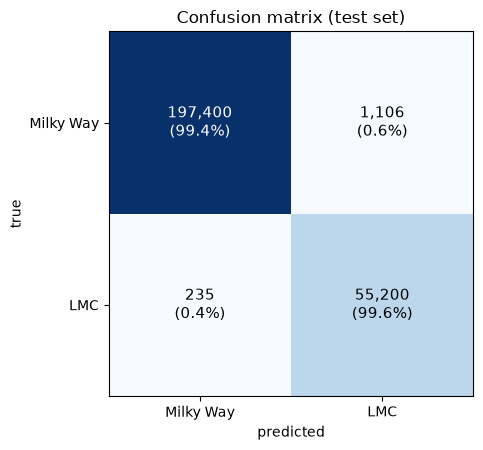

LMC stars correctly kept (recall):     55,200 / 55,435  = 99.58%
Milky Way wrongly called LMC (contam.): 1,106 / 198,506  = 0.56%


In [8]:
cm = confusion_matrix(y_te, y_pred)
labels = ["Milky Way", "LMC"]

fig, ax = plt.subplots(figsize=(5.2, 4.6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0,1], labels); ax.set_yticks([0,1], labels)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix (test set)")
for i in range(2):
    row = cm[i].sum()
    for j in range(2):
        ax.text(j, i, f"{cm[i,j]:,}\n({100*cm[i,j]/row:.1f}%)",
                ha="center", va="center",
                color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=11)
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"LMC stars correctly kept (recall):     {tp:,} / {tp+fn:,}  = {100*tp/(tp+fn):.2f}%")
print(f"Milky Way wrongly called LMC (contam.): {fp:,} / {fp+tn:,}  = {100*fp/(fp+tn):.2f}%")

## 7. What the model learned: feature importance

Which features drove the decisions? If the physics from notebook 01 is real, motion and
parallax should dominate.

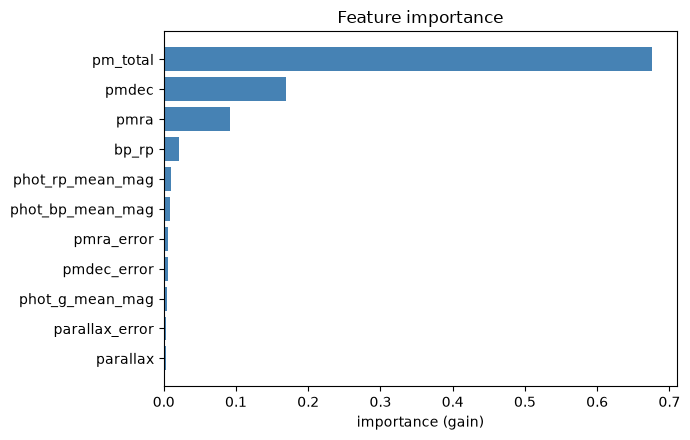

  pm_total             0.6763
  pmdec                0.1690
  pmra                 0.0918
  bp_rp                0.0211
  phot_rp_mean_mag     0.0103
  phot_bp_mean_mag     0.0089
  pmra_error           0.0065
  pmdec_error          0.0059
  phot_g_mean_mag      0.0039
  parallax_error       0.0033
  parallax             0.0031


In [9]:
imp = clf.feature_importances_
order = np.argsort(imp)[::-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh([FEATURES[i] for i in order][::-1], imp[order][::-1], color="steelblue")
ax.set_xlabel("importance (gain)")
ax.set_title("Feature importance")
plt.tight_layout(); plt.show()
for i in order:
    print(f"  {FEATURES[i]:20s} {imp[i]:.4f}")

## 8. Save the model

Persist the trained classifier and the feature list so notebook 03 (validate on real
Cepheids/RR Lyrae) and 04 (apply to the base sample) can load exactly this model.

In [10]:
import json
joblib.dump(clf, OUT / "xgb_baseline.joblib")
(OUT / "feature_cols.json").write_text(json.dumps(FEATURES, indent=2))
print("saved:", OUT / "xgb_baseline.joblib")
print("saved:", OUT / "feature_cols.json")

saved: ../outputs/xgb_baseline.joblib
saved: ../outputs/feature_cols.json


## Summary

- Trained an XGBoost classifier on **physical features only** (motion, distance, photometry) —
  deliberately excluding sky position so the result is a genuine, generalizable membership model.
- Handled the 78/22 imbalance with `scale_pos_weight`.
- Reported honest held-out metrics with emphasis on **LMC recall** (not losing real members) and
  **Milky Way contamination** (not polluting the catalogue).

**Next (notebook 03): the real-world test.** Run this model on the 4,485 Cepheids and 22,006
RR Lyrae — confirmed LMC members from actual Gaia observations. A trustworthy model should tag
almost all of them as LMC. That is the check that the simulation-trained model works on real sky.
